# Analyze Factors Influencing Airbnb Listing Price in NYC

**Authors:** Wendy Fu & Kerry Zhang

This project analyzes Airbnb listings in New York City using data from Inside Airbnb. The goal is to understand which listing, location, host, availability, and review-related factors are associated with nightly listing price, and to build regression models that predict price.

## 1. Project Goals

The main questions in this project are:

1. How does listing price vary across boroughs, neighborhoods, and room types?
2. Which features appear most related to nightly price?
3. Can simple machine learning models predict listing price reasonably well?
4. What practical pricing insights can Airbnb hosts take from the analysis?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme()
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load Data

The dataset is the New York City detailed listings file from Inside Airbnb, dated November 1, 2025. The file contains listing information, host attributes, location variables, availability variables, and review metrics.

In [2]:
df = pd.read_csv("listings.csv", low_memory=False)

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (36353, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1274691077561855573,https://www.airbnb.com/rooms/1274691077561855573,20251101201932,2025-11-02,city scrape,Beautiful room for rent hosted by Svitlana,Cozy Room for Rent in a Two-Bedroom Apartment<...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,658783772,...,5.0,5.0,5.0,OSE-STRREG-0002773,f,1,0,1,0,1.62
1,1274722590671904755,https://www.airbnb.com/rooms/1274722590671904755,20251101201932,2025-11-02,city scrape,Exquisite & Charming Studio in Prime Locations,This stylish place to stay is perfect for grou...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,458668555,...,5.0,4.5,5.0,NaN,f,6,0,6,0,0.21
2,1274773188072371454,https://www.airbnb.com/rooms/1274773188072371454,20251101201932,2025-11-02,city scrape,"Private 2 Bedroom Unit, Full Kitchen, Washer/D...",This stylish place to stay is perfect for trav...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,22369387,...,NaN,NaN,NaN,NaN,f,3,2,1,0,NaN
3,1274820999428562667,https://www.airbnb.com/rooms/1274820999428562667,20251101201932,2025-11-02,city scrape,"Beautiful, Serene West Village Treehouse",Switch off in this serene one-bedroom oasis on...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,505544503,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
4,1274826163511555978,https://www.airbnb.com/rooms/1274826163511555978,20251101201932,2025-11-02,city scrape,Renovated 1BR w/ Spa Shower,Newly renovated 1-bedroom oasis in vibrant Dow...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,493151605,...,5.0,4.0,5.0,NaN,f,4,2,2,0,0.10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36353 entries, 0 to 36352
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36353 non-null  int64  
 1   listing_url                                   36353 non-null  object 
 2   scrape_id                                     36353 non-null  int64  
 3   last_scraped                                  36353 non-null  object 
 4   source                                        36353 non-null  object 
 5   name                                          36351 non-null  object 
 6   description                                   35178 non-null  object 
 7   neighborhood_overview                         18748 non-null  object 
 8   picture_url                                   36353 non-null  object 
 9   host_id                                       36353 non-null 

## 3. Data Cleaning

The original `price` column is stored as text, such as `$87.00`. This must be converted to a numeric variable before analysis. Listings with missing prices cannot be used for price prediction, so they are removed from the modeling dataset.

Airbnb prices are also highly skewed. A few extremely expensive listings can strongly affect averages and regression models. To reduce the effect of extreme outliers, this notebook keeps listings between the 1st and 99th percentile of price.

In [4]:
# Make a copy so the original dataframe stays unchanged.
data = df.copy()

# The price column has dollar signs and commas, so it needs to be cleaned before analysis
data["price"] = data["price"].astype(str)
data["price"] = data["price"].str.replace("$", "", regex=False)
data["price"] = data["price"].str.replace(",", "", regex=False)
data["price"] = pd.to_numeric(data["price"], errors="coerce")

print("Original rows:", len(data))
print("Rows with usable price:", data["price"].notna().sum())
print("Missing price percentage:", round(data["price"].isna().mean() * 100, 2), "%")

# Prices need to be positive.
data = data.dropna(subset=["price"])
data = data[data["price"] > 0]

# Remove the lowest 1% and highest 1% of prices to reduce outliers
lower_price = data["price"].quantile(0.01)
upper_price = data["price"].quantile(0.99)
data = data[(data["price"] >= lower_price) & (data["price"] <= upper_price)]

print("Rows after price cleaning:", len(data))
print("Kept price range:", lower_price, "to", upper_price)

Original rows: 36353
Rows with usable price: 21415
Missing price percentage: 41.09 %
Rows after price cleaning: 21011
Kept price range: 36.0 to 2266.1600000000035


In [5]:
# Convert percentage columns from text into numeric values.
for col in ["host_response_rate", "host_acceptance_rate"]:
    data[col] = data[col].astype(str).str.replace("%", "", regex=False)
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Convert true/false columns into 1/0 so they can be used by sklearn models.
for col in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]:
    data[col] = data[col].map({"t": 1, "f": 0})

# Create a simple feature for how long the host has been on Airbnb.
data["host_since"] = pd.to_datetime(data["host_since"], errors="coerce")
data["host_years"] = 2025 - data["host_since"].dt.year

# These simple engineered features may capture regulation status and listing detail.
data["has_license"] = data["license"].notna().astype(int)
data["amenities_count"] = data["amenities"].fillna("").apply(lambda x: 0 if x == "" else x.count(",") + 1)


data[["price", "host_response_rate", "host_acceptance_rate", "host_years", "amenities_count"]].head()

,price,host_response_rate,host_acceptance_rate,host_years,amenities_count
0,87.0,100.0,97.0,1.0,11
1,80.0,100.0,100.0,3.0,51
2,99.0,100.0,67.0,11.0,34
3,312.0,50.0,20.0,2.0,32
4,111.0,100.0,100.0,3.0,30


## 4. Exploratory Data Analysis

The EDA section looks beyond only obvious statements such as "Manhattan is expensive." The goal is to compare price differences across combinations of location, room type, capacity, reviews, and host behavior.

In [6]:
data["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    21011.000000
mean       213.561849
std        204.546035
min         36.000000
1%          40.000000
5%          48.000000
25%         90.000000
50%        154.000000
75%        264.000000
95%        563.000000
99%       1058.700000
max       2261.000000
Name: price, dtype: float64

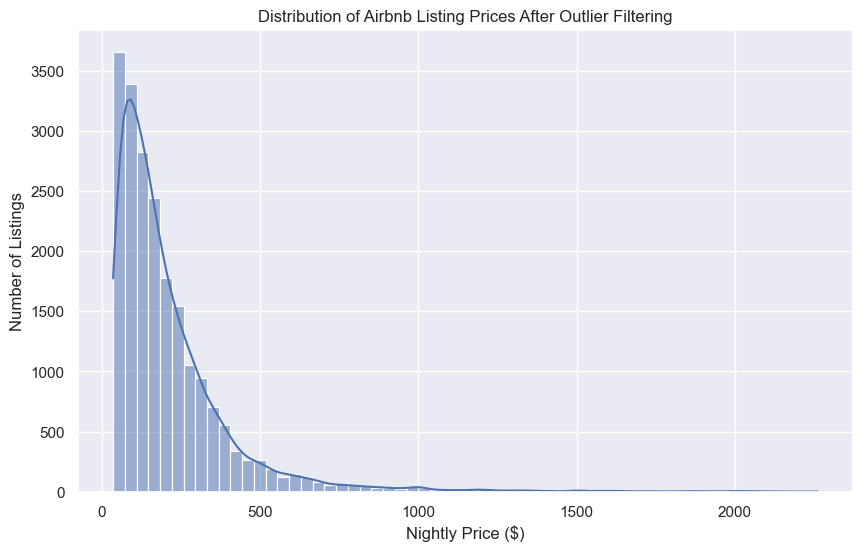

In [7]:
sns.histplot(data["price"], bins=60, kde=True)
plt.title("Distribution of Airbnb Listing Prices After Outlier Filtering")
plt.xlabel("Nightly Price ($)")
plt.ylabel("Number of Listings")
plt.show()

**Interpretation:** The price distribution is right-skewed even after removing extreme outliers. Most listings are below the high-price tail, which means median prices are often more informative than means.

In [8]:
borough_summary = (data.groupby("neighbourhood_group_cleansed")["price"]
                   .agg(["count", "mean", "median"])
                   .sort_values("median", ascending=False)
                   )

borough_summary

,count,mean,median
neighbourhood_group_cleansed,,,
Manhattan,9350,283.190588,222.0
Brooklyn,7226,172.821063,135.0
Queens,3324,136.147413,103.0
Staten Island,311,127.437299,100.0
Bronx,800,122.905000,95.0


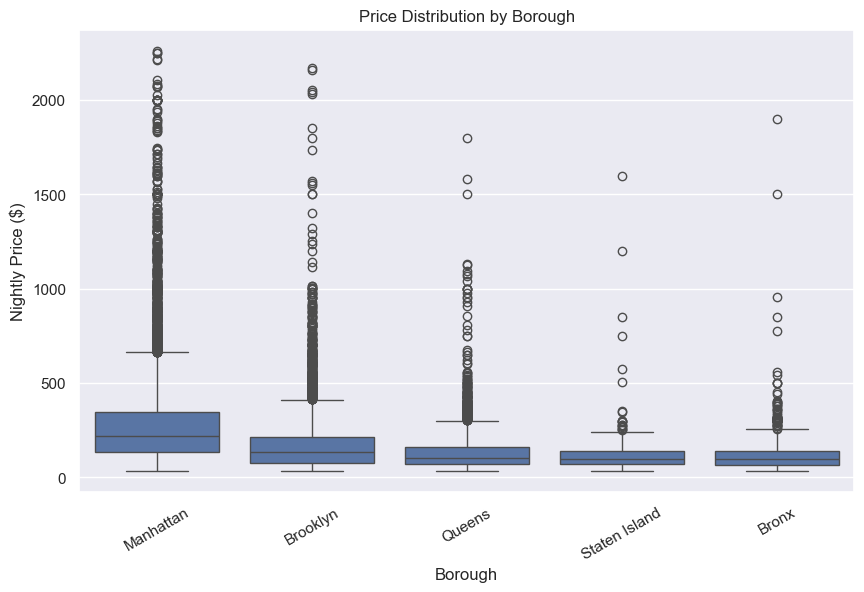

In [ ]:
sns.boxplot(data=data,x="neighbourhood_group_cleansed", y="price", order=borough_summary.index)
plt.title("Price Distribution by Borough")
plt.xlabel("Borough")
plt.ylabel("Nightly Price ($)")
plt.xticks(rotation=30)
plt.show()

**Interpretation:** Borough matters, but the boxplot also shows overlap. Some listings outside Manhattan still have high prices, so location alone is not enough to explain price.

In [ ]:
# This table checks whether room type matters differently in each borough
room_borough = pd.pivot_table(
    data,
    values="price",
    index="neighbourhood_group_cleansed",
    columns="room_type",
    aggfunc="median"
)

room_borough

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood_group_cleansed,,,,
Bronx,134.0,NaN,70.0,NaN
Brooklyn,188.0,381.0,80.0,115.0
Manhattan,250.0,447.0,117.0,61.0
Queens,155.0,246.5,77.0,103.0
Staten Island,118.0,NaN,80.0,128.0


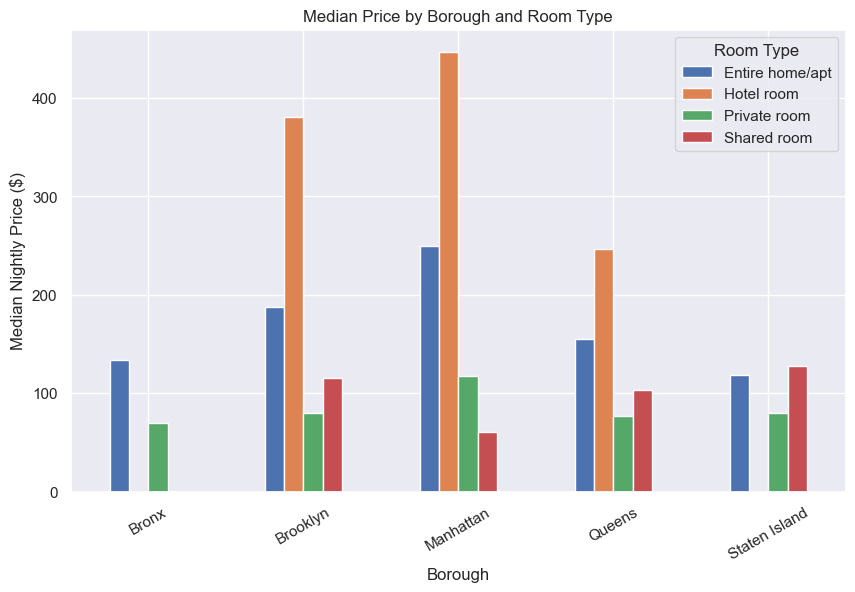

In [11]:
room_borough.plot(kind="bar")
plt.title("Median Price by Borough and Room Type")
plt.xlabel("Borough")
plt.ylabel("Median Nightly Price ($)")
plt.xticks(rotation=30)
plt.legend(title="Room Type")
plt.show()

**Interpretation:** This chart is more useful than simply saying Manhattan is expensive. It shows whether the price premium of an entire home is similar across boroughs, or whether some boroughs have a larger gap between entire homes and private rooms.

In [12]:
# Limiting to accommodates <= 10 keeps the chart focused on common listing sizes.
capacity_summary = (
    data[data["accommodates"] <= 10]
    .groupby("accommodates")["price"]
    .agg(["count", "median", "mean"])
)

capacity_summary["median_price_increase"] = capacity_summary["median"].diff()
capacity_summary

,count,median,mean,median_price_increase
accommodates,,,,
1,3558,66.0,83.596402,NaN
2,9618,143.0,189.505303,77.0
3,1676,177.5,202.270883,34.5
4,3274,220.0,277.948992,42.5
5,794,235.5,291.151134,15.5
6,1121,286.0,354.223907,50.5
7,203,307.0,402.004926,21.0
8,436,360.0,448.667431,53.0
9,64,404.0,473.453125,44.0


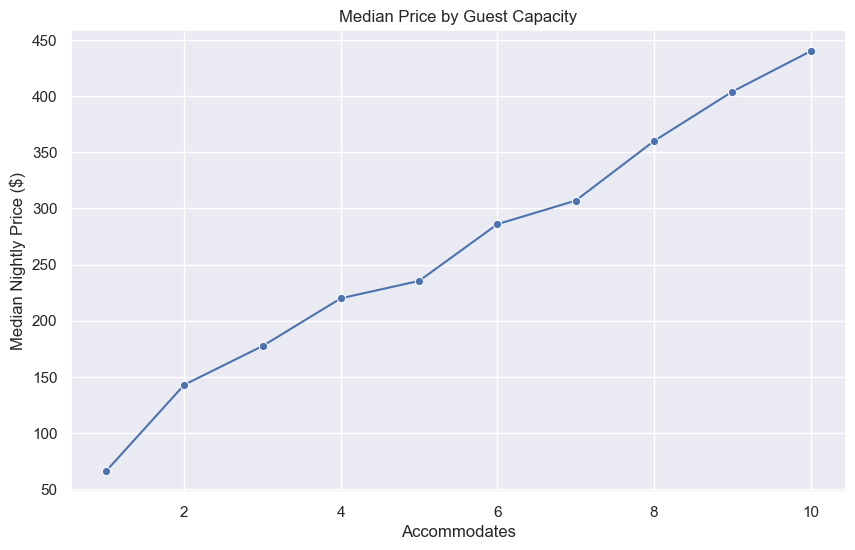

In [13]:
sns.lineplot(data=capacity_summary, x=capacity_summary.index, y="median", marker="o")
plt.title("Median Price by Guest Capacity")
plt.xlabel("Accommodates")
plt.ylabel("Median Nightly Price ($)")
plt.show()

**Interpretation:** The table and line chart help identify marginal returns. If the price increase gets smaller at higher guest capacities, then adding more capacity may have diminishing returns.

In [14]:
# Use the most common neighborhoods so each comparison has enough listings.
top_neighborhoods = data["neighbourhood_cleansed"].value_counts().head(15).index

neighborhood_summary = (
    data[data["neighbourhood_cleansed"].isin(top_neighborhoods)]
    .groupby("neighbourhood_cleansed")["price"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

neighborhood_summary

,count,median,mean
neighbourhood_cleansed,,,
Financial District,374,341.5,417.358289
Midtown,1255,300.0,370.909163
Chelsea,539,250.0,296.662338
Lower East Side,340,217.0,278.579412
Hell's Kitchen,1030,215.0,272.329126
East Village,422,200.0,271.765403
Upper East Side,942,200.0,256.623142
Upper West Side,830,200.0,252.268675
Williamsburg,824,164.0,205.910194


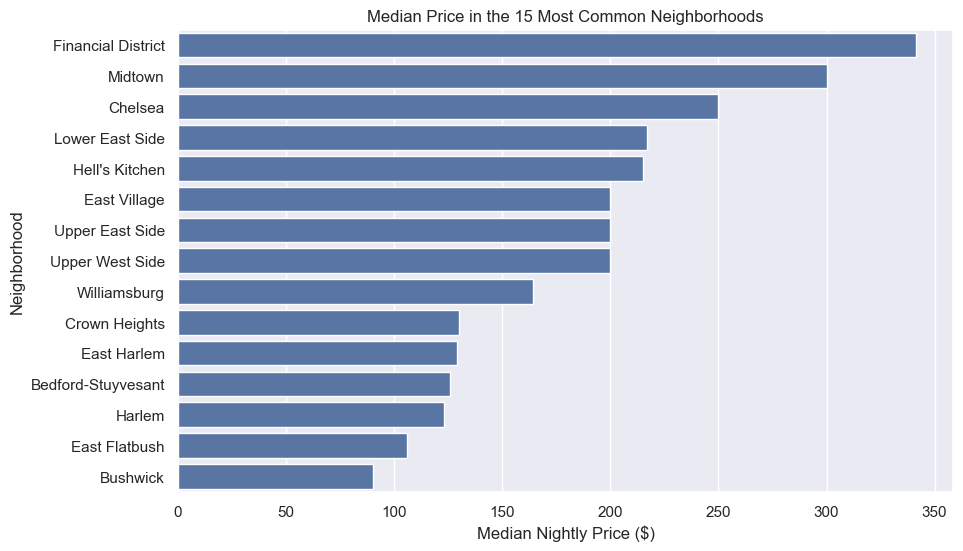

In [15]:
sns.barplot(
    data=neighborhood_summary.reset_index(),
    x="median",
    y="neighbourhood_cleansed"
)
plt.title("Median Price in the 15 Most Common Neighborhoods")
plt.xlabel("Median Nightly Price ($)")
plt.ylabel("Neighborhood")
plt.show()

**Interpretation:** Neighborhood-level analysis gives a more detailed location insight than borough-level analysis. Within the same borough, neighborhoods can have different price levels.

In [16]:
review_cols = [
    "price",
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value"
]

data[review_cols].corr(numeric_only=True)["price"].sort_values(ascending=False)

price                        1.000000
review_scores_location       0.107719
reviews_per_month            0.079678
review_scores_cleanliness    0.074739
review_scores_rating         0.044741
review_scores_value          0.004541
number_of_reviews           -0.029055
Name: price, dtype: float64

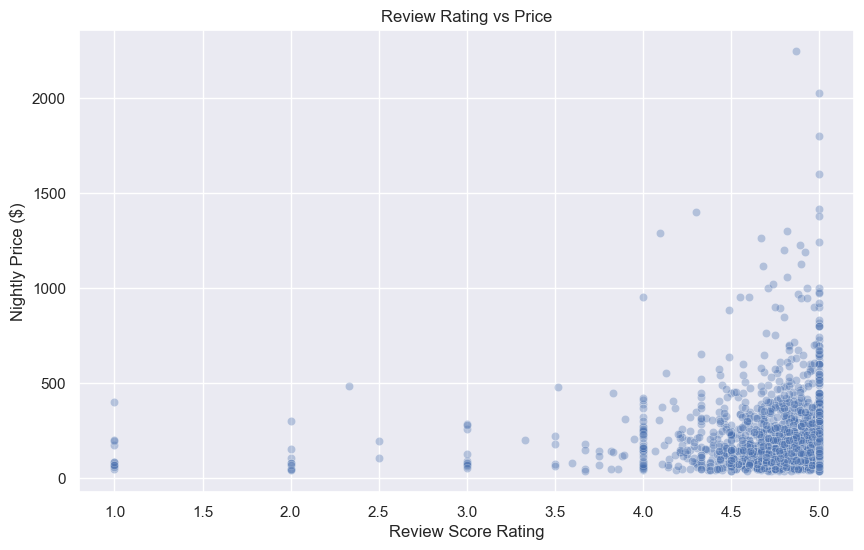

In [17]:
sns.scatterplot(
    data=data.sample(min(3000, len(data)), random_state=42),
    x="review_scores_rating",
    y="price",
    alpha=0.35
)
plt.title("Review Rating vs Price")
plt.xlabel("Review Score Rating")
plt.ylabel("Nightly Price ($)")
plt.show()

**Interpretation:** Review scores may not strongly explain price because many listings have ratings close to the top of the scale. This means a high rating may be more of a basic requirement than a strong price differentiator.

In [18]:
# This simple split compares hosts with many listings to smaller individual hosts.
data["host_type"] = np.where(data["calculated_host_listings_count"] >= 5, "Professional host", "Small host")

host_summary = (
    data.groupby("host_type")
    .agg(
        listings=("id", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_availability=("availability_365", "median"),
        median_minimum_nights=("minimum_nights", "median")
    )
)

host_summary

,listings,median_price,mean_price,median_availability,median_minimum_nights
host_type,,,,,
Professional host,8648,179.0,233.396508,304.0,30.0
Small host,12363,148.0,199.687374,270.0,30.0


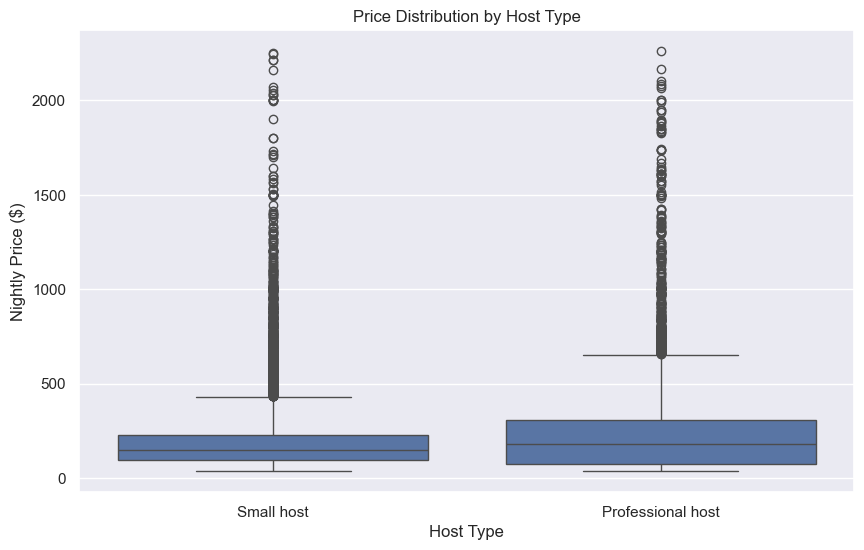

In [19]:
sns.boxplot(data=data, x="host_type", y="price")
plt.title("Price Distribution by Host Type")
plt.xlabel("Host Type")
plt.ylabel("Nightly Price ($)")
plt.show()

**Interpretation:** This comparison checks whether hosts with many listings follow a different pricing pattern from smaller hosts. It also connects price to operational strategy, not just property characteristics.

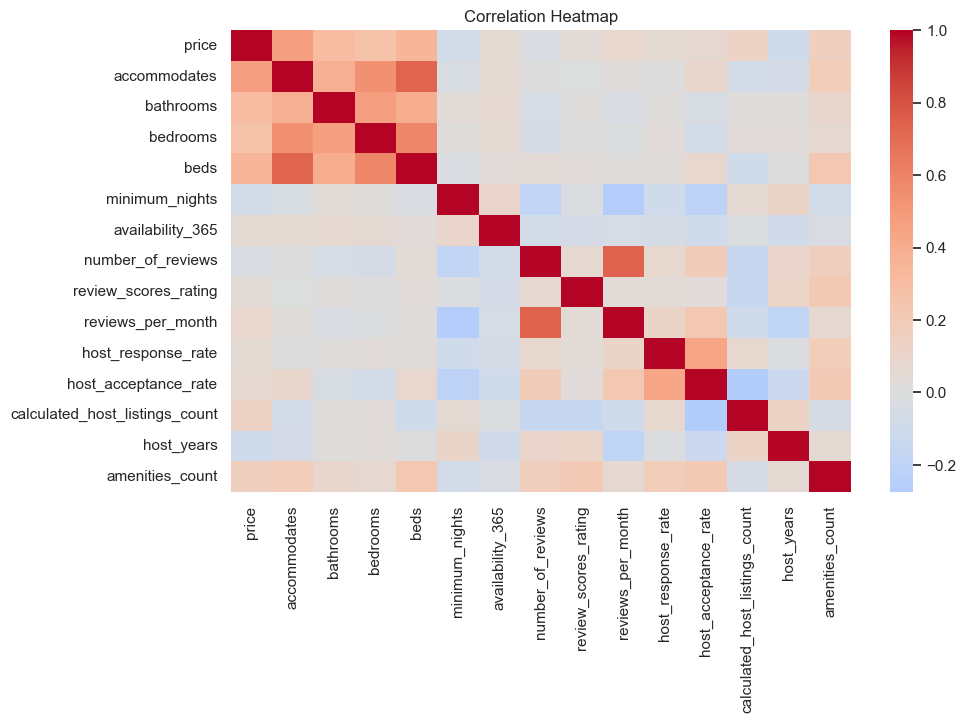

In [20]:
numeric_for_corr = [
    "price", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "availability_365", "number_of_reviews",
    "review_scores_rating", "reviews_per_month", "host_response_rate",
    "host_acceptance_rate", "calculated_host_listings_count",
    "host_years", "amenities_count"
]

corr = data[numeric_for_corr].corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 5. Machine Learning Setup

The target variable is `price`. The model features include location, room type, property type, capacity, host behavior, availability, review metrics, and engineered features.

The models used are:

- **Linear Regression:** a simple baseline model.
- **Ridge Regression:** a regularized linear model that is more stable when many one-hot encoded features are used.
- **Decision Tree Regressor:** a non-linear model that can capture feature interactions, but may overfit.
- **Random Forest Regressor:** an ensemble of decision trees that usually gives stronger and more stable predictions.

In [21]:
features = [
    "neighbourhood_group_cleansed",
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "reviews_per_month",
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_identity_verified",
    "instant_bookable",
    "calculated_host_listings_count",
    "host_years",
    "has_license",
    "amenities_count"
]

# Keep only the columns needed for modeling.
model_data = data[features + ["price"]].copy()

X = model_data[features]
y = model_data["price"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['neighbourhood_group_cleansed', 'neighbourhood_cleansed', 'room_type', 'property_type']
Numeric features: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_identity_verified', 'instant_bookable', 'calculated_host_listings_count', 'host_years', 'has_license', 'amenities_count']


In [22]:
# Split the data so performance is tested on listings the model has not seen before.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Numeric columns use median imputation because it is simple and less affected by skewed values.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical columns are converted into dummy variables with one-hot encoding.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [23]:
# This helper function trains each model and calculates the same metrics for comparison.
def evaluate_model(name, model):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pipeline": pipeline
    }

In [24]:
results = []

results.append(evaluate_model("Linear Regression", LinearRegression()))
results.append(evaluate_model("Ridge Regression", Ridge(alpha=1.0)))
results.append(evaluate_model("Decision Tree", DecisionTreeRegressor(max_depth=12, random_state=42)))
results.append(evaluate_model("Random Forest", RandomForestRegressor(n_estimators=100, max_depth=18, random_state=42)))

metrics = pd.DataFrame([
    {"Model": r["Model"], "MAE": r["MAE"], "RMSE": r["RMSE"], "R2": r["R2"]}
    for r in results
]).sort_values("MAE")

metrics

,Model,MAE,RMSE,R2
3,Random Forest,60.745100,129.124578,0.615414
2,Decision Tree,71.493774,150.427669,0.478047
1,Ridge Regression,85.933601,153.459534,0.456795
0,Linear Regression,86.055402,153.469275,0.456726


**Model interpretation:** MAE is the easiest metric to explain because it gives the average prediction error in dollars. RMSE is also useful because it penalizes large errors more strongly. R² shows how much variation in price the model explains.

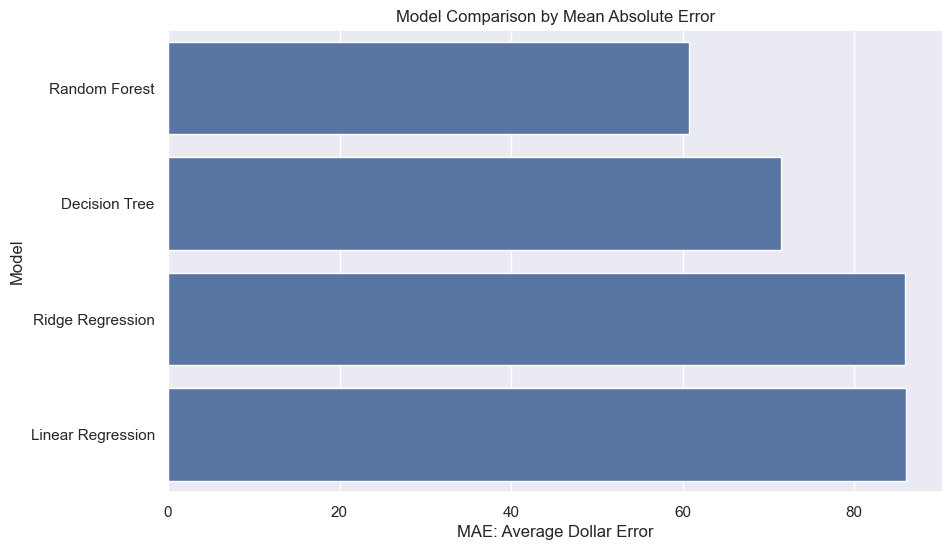

In [25]:
sns.barplot(data=metrics, x="MAE", y="Model")
plt.title("Model Comparison by Mean Absolute Error")
plt.xlabel("MAE: Average Dollar Error")
plt.ylabel("Model")
plt.show()

## 6. Feature Importance

Random Forest is useful for feature importance because it can estimate which variables contributed most to prediction. This does not prove causation, but it helps identify the strongest pricing signals in the dataset.

In [26]:
# Use the Random Forest model to inspect which features were most useful for prediction.
best_result = [r for r in results if r["Model"] == "Random Forest"][0]
best_pipeline = best_result["Pipeline"]

onehot_names = best_pipeline.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(onehot_names)

importances = best_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
0,accommodates,0.179521
1,bathrooms,0.124210
28,neighbourhood_group_cleansed_Manhattan,0.074398
22,calculated_host_listings_count,0.072496
25,amenities_count,0.049909
4,minimum_nights,0.047268
23,host_years,0.031301
9,availability_365,0.022143
8,availability_90,0.021067
18,host_acceptance_rate,0.020704


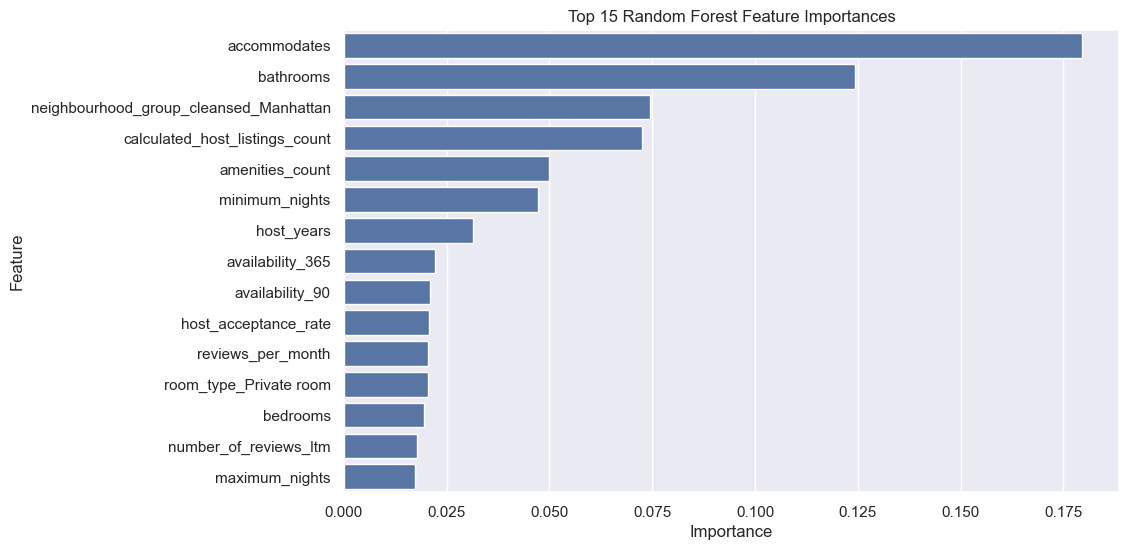

In [27]:
top_importance = importance_df.head(15)

sns.barplot(data=top_importance, x="importance", y="feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 7. Main Insights

The analysis should be interpreted as evidence about listed prices, not confirmed booking revenue. Based on the EDA and modeling results, the most useful insights are:

1. **Location matters, but borough alone is too broad.** Manhattan tends to be expensive, but neighborhood and room type explain important differences within and across boroughs.

2. **Room type is one of the most important pricing factors.** The price gap between an entire home and a private room can be larger than some borough-level differences.

3. **Capacity has marginal effects.** Listings that accommodate more guests usually charge more, but the increase may not be equal at every capacity level. This suggests possible diminishing returns.

4. **Review scores may be weaker price predictors than expected.** Since many listings have high ratings, ratings may act more like a minimum quality signal than a major price driver.

5. **Host behavior and availability help describe pricing strategy.** Hosts with many listings, different minimum-night rules, and different availability patterns may be operating in different market segments.

6. **Tree-based models are expected to perform better than simple linear models.** Airbnb price depends on combinations of features, such as borough plus room type plus capacity, so non-linear models can capture these patterns better.

## 8. Host-Facing Recommendations

- Hosts should compare their prices with similar listings in the same borough, neighborhood, and room type instead of using only citywide averages.
- Hosts should pay attention to the price premium of entire homes compared with private rooms in their own borough.
- Increasing guest capacity may raise price, but hosts should check whether the marginal price increase is large enough to justify the cost of supporting more guests.
- High review scores are important, but they may not automatically allow a listing to charge much more because many listings already have high ratings.
- Availability and minimum-night rules should match the host's strategy. Short-stay tourist listings and longer-stay listings may compete in different price segments.

## 9. Limitations

- This dataset is a snapshot of listed prices, not final booked prices.
- Many listings have missing price values, so the analysis only uses listings with available prices.
- The model shows association, not causation. A feature being important does not prove that changing that feature will directly cause a higher price.
- The dataset does not include all possible demand factors, such as events, seasonality, exact booking dates, or competitor changes over time.
- Extremely high prices were filtered to make the analysis more stable, so the conclusions are focused on typical listings rather than luxury outliers.

## 10. Conclusion

This project finds that Airbnb listing price in New York City is influenced by a combination of location, room type, guest capacity, host behavior, availability, and review-related features. The most practical finding is that hosts should not rely on broad rules such as "Manhattan is expensive" or "more bedrooms mean higher price." More useful pricing decisions come from comparing similar listings by neighborhood, room type, and capacity, while also considering operating strategy such as availability and minimum-night requirements.